# Classification Assignment
## Framingham Heart Study - 10 Year CHD Prediction
**Dataset:** framingham.csv  
**Target:** TenYearCHD (0 = No Risk, 1 = Risk)

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# Seaborn style set karo
sns.set_theme(style='whitegrid')

print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2: Load and Analyze Dataset

In [2]:
# Dataset load karo
df = pd.read_csv('framingham.csv')

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (4238, 16)

First 5 rows:


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
# Basic info
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB

In [4]:
# Statistical summary
print('Statistical Summary:')
df.describe()

Statistical Summary:


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [5]:
# Target class distribution check karo
print('Target Column Distribution:')
print(df['TenYearCHD'].value_counts())
print('\nPercentage:')
print(df['TenYearCHD'].value_counts(normalize=True) * 100)

Target Column Distribution:
TenYearCHD
0    3594
1     644
Name: count, dtype: int64

Percentage:
TenYearCHD
0    84.804153
1    15.195847
Name: proportion, dtype: float64


## Step 3: Handle Missing Values

In [6]:
# Missing values check karo
print('Missing Values per Column:')
print(df.isnull().sum())
print('\nTotal Missing Values:', df.isnull().sum().sum())

Missing Values per Column:
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Total Missing Values: 645


In [7]:
# Missing values ko median se fill karo (numerical columns ke liye best approach)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'{col} - missing values filled with median')

print('\nMissing values after handling:', df.isnull().sum().sum())

education - missing values filled with median
cigsPerDay - missing values filled with median
BPMeds - missing values filled with median
totChol - missing values filled with median
BMI - missing values filled with median
heartRate - missing values filled with median
glucose - missing values filled with median

Missing values after handling: 0


## Step 4: Exploratory Data Analysis (EDA) with Plots
**Note: Sirf Seaborn use kiya gaya hai plotting ke liye**

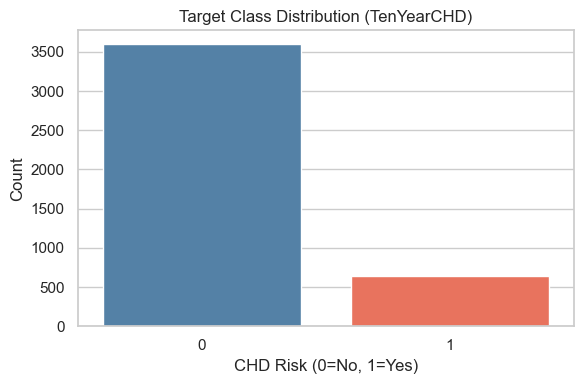

In [8]:
# Target class distribution - Seaborn countplot
plt.figure(figsize=(6, 4))
sns.countplot(x='TenYearCHD', data=df, palette=['steelblue', 'tomato'])
plt.title('Target Class Distribution (TenYearCHD)')
plt.xlabel('CHD Risk (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

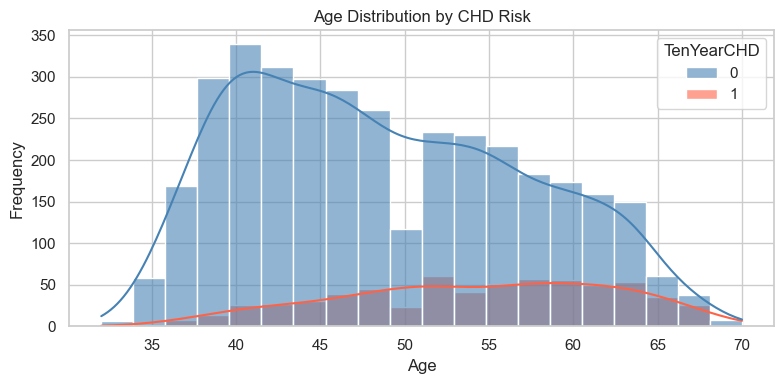

In [9]:
# Age distribution by CHD - Seaborn histplot
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='age', hue='TenYearCHD', kde=True,
             palette=['steelblue', 'tomato'], alpha=0.6, bins=20)
plt.title('Age Distribution by CHD Risk')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

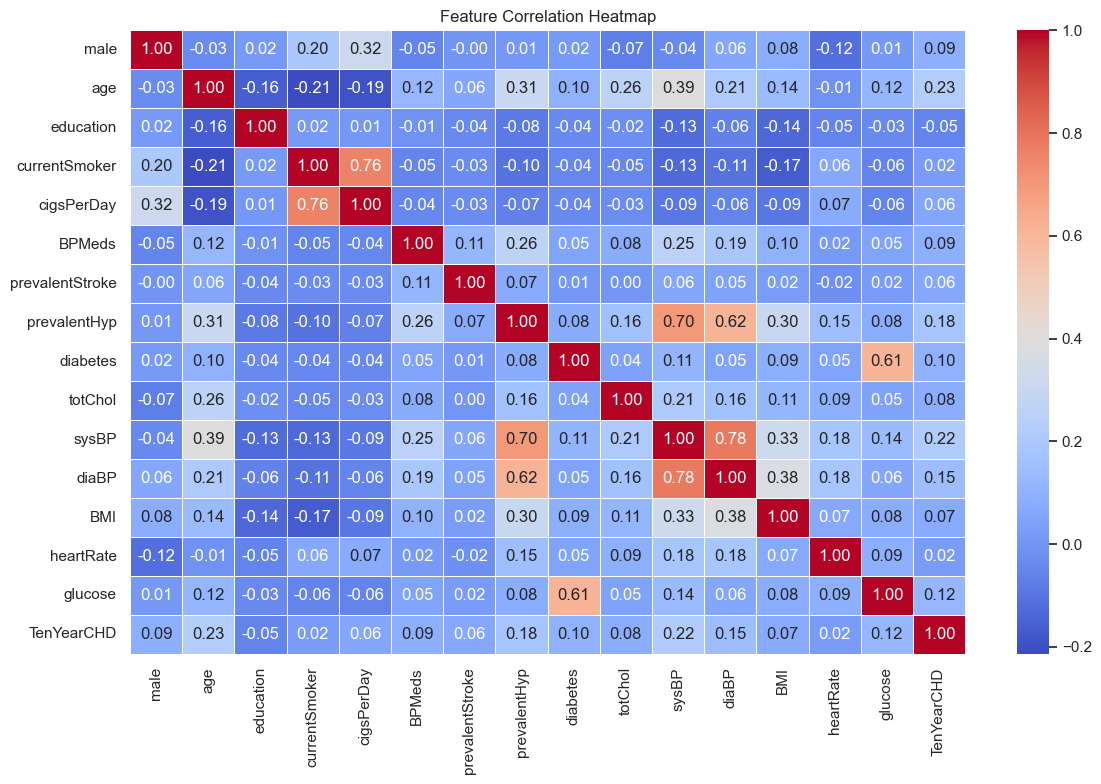

In [10]:
# Correlation heatmap - Seaborn heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Step 5: Feature Scaling

In [11]:
# Features aur target alag karo
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (4238, 15)
Target shape: (4238,)


In [12]:
# StandardScaler apply karo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature scaling applied successfully!')
print('Scaled features mean (approx 0):', X_scaled.mean().round(2))

Feature scaling applied successfully!
Scaled features mean (approx 0): 0.0


## Step 6: Handle Imbalanced Dataset using SMOTE

In [13]:
# SMOTE se imbalance handle karo
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print('Before SMOTE:', y.value_counts().to_dict())
print('After SMOTE:', pd.Series(y_resampled).value_counts().to_dict())

Before SMOTE: {0: 3594, 1: 644}
After SMOTE: {0: 3594, 1: 3594}


In [14]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (5750, 15)
Test size: (1438, 15)


## Step 7: Train Multiple Classification Models

In [15]:
# 3 models train karo aur compare karo
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                    'Recall': rec, 'F1-Score': f1})
    
    print(f'\n--- {name} ---')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall:    {rec:.4f}')
    print(f'F1-Score:  {f1:.4f}')

results_df = pd.DataFrame(results)
print('\n\nModel Comparison Table:')
results_df


--- Logistic Regression ---
Accuracy:  0.6794
Precision: 0.6526
Recall:    0.7012
F1-Score:  0.6760

--- Decision Tree ---
Accuracy:  0.7907
Precision: 0.7655
Recall:    0.8090
F1-Score:  0.7867



--- Random Forest ---
Accuracy:  0.8957
Precision: 0.8829
Recall:    0.9009
F1-Score:  0.8918


Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.679416,0.652646,0.701166,0.676037
1,Decision Tree,0.790682,0.765517,0.809038,0.786676
2,Random Forest,0.895688,0.882857,0.900875,0.891775


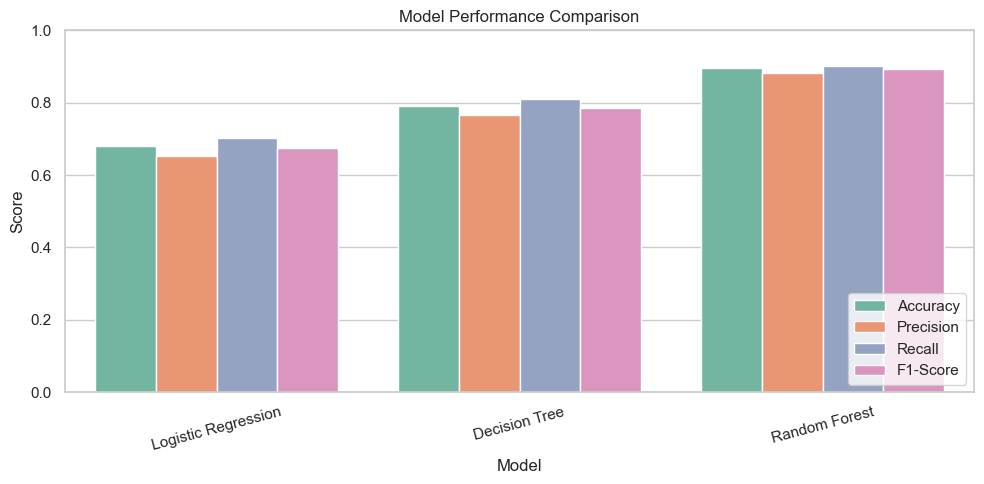

In [16]:
# Models comparison bar chart - Seaborn barplot
results_melted = results_df.melt(id_vars='Model',
                                  value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                                  var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 5))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', palette='Set2')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Step 8: Best Model - Classification Report & Confusion Matrix

In [17]:
# Best model select karo (highest F1-Score wala)
best_model_name = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_model = models[best_model_name]

print(f'Best Model: {best_model_name}')
y_pred_best = best_model.predict(X_test)

print('\nClassification Report:')
print(classification_report(y_test, y_pred_best, target_names=['No CHD', 'CHD Risk']))

Best Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

      No CHD       0.91      0.89      0.90       752
    CHD Risk       0.88      0.90      0.89       686

    accuracy                           0.90      1438
   macro avg       0.90      0.90      0.90      1438
weighted avg       0.90      0.90      0.90      1438



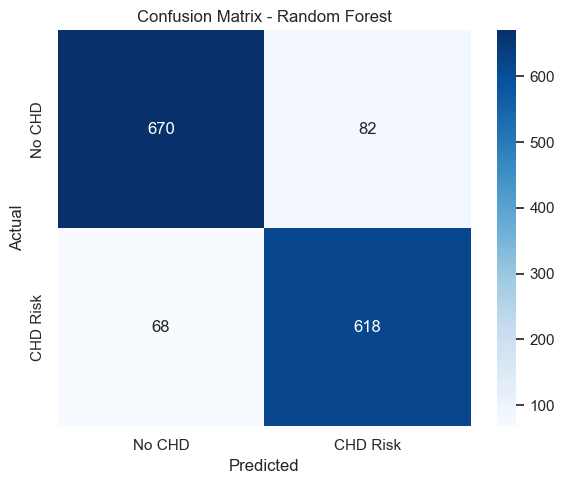

In [18]:
# Confusion Matrix - Seaborn heatmap
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No CHD', 'CHD Risk'],
            yticklabels=['No CHD', 'CHD Risk'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Step 9: Hyperparameter Tuning (GridSearchCV)

In [19]:
# Random Forest ka hyperparameter tuning karo
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best Parameters:', grid_search.best_params_)
print('Best CV F1-Score:', round(grid_search.best_score_, 4))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1-Score: 0.8873


In [20]:
# Tuned model evaluate karo
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)

print('--- Tuned Random Forest Performance ---')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_tuned):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_tuned):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_tuned):.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_tuned, target_names=['No CHD', 'CHD Risk']))

--- Tuned Random Forest Performance ---
Accuracy:  0.9096
Precision: 0.8971
Recall:    0.9155
F1-Score:  0.9062

Classification Report:
              precision    recall  f1-score   support

      No CHD       0.92      0.90      0.91       752
    CHD Risk       0.90      0.92      0.91       686

    accuracy                           0.91      1438
   macro avg       0.91      0.91      0.91      1438
weighted avg       0.91      0.91      0.91      1438



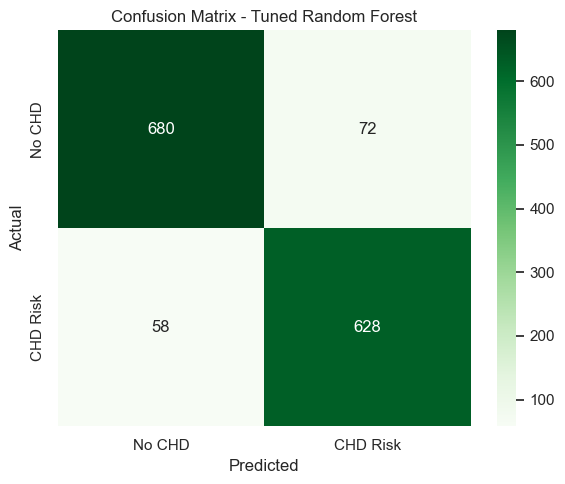

In [21]:
# Tuned model Confusion Matrix - Seaborn heatmap
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No CHD', 'CHD Risk'],
            yticklabels=['No CHD', 'CHD Risk'])
plt.title('Confusion Matrix - Tuned Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Step 10: Feature Importance

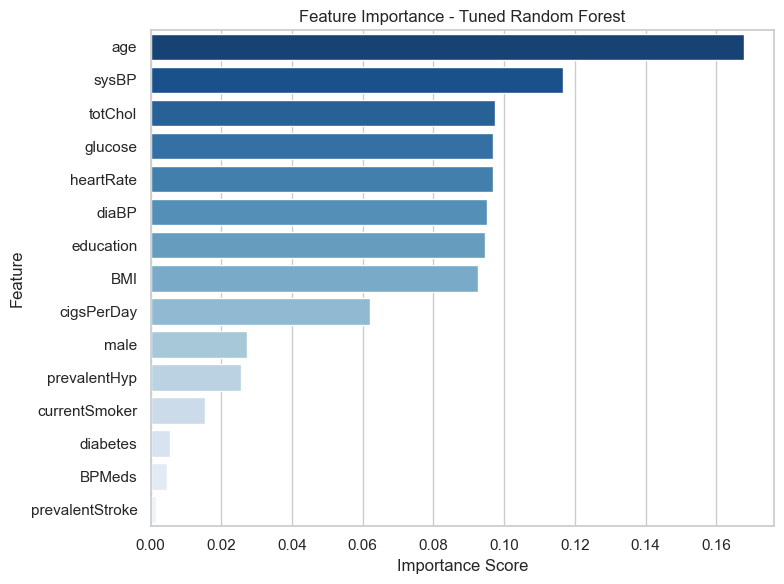

In [22]:
# Feature importance - Seaborn barplot
feature_names = X.columns.tolist()
importances = tuned_model.feature_importances_

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Feature Importance - Tuned Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Final Summary

| Step | Action |
|------|--------|
| 1 | Libraries import ki gayi (Seaborn for plotting) |
| 2 | Dataset load aur analyze kiya gaya |
| 3 | Missing values median se fill ki gayi |
| 4 | EDA plots Seaborn se banaye gaye |
| 5 | StandardScaler se feature scaling ki gayi |
| 6 | SMOTE se imbalanced dataset balance kiya gaya |
| 7 | 3 models train aur compare kiye gaye |
| 8 | Best model ki Classification Report aur Confusion Matrix dekhi |
| 9 | GridSearchCV se hyperparameter tuning ki gayi |
| 10 | Feature importance Seaborn se plot kiya gaya |

**Best Model: Tuned Random Forest Classifier**